In [1]:
!pip install -q yellowbrick

In [4]:
#import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import pickle

In [7]:
#Load Data Set
df = pd.read_csv("/content/feature_engineered_data.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName,Day,DayOfWeek,Hour,Quarter,IsWeekend,BasketSize,OrderValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009.0,12.0,December,1.0,Tuesday,7.0,4.0,0.0,166.0,505.3


In [12]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce",
    format="mixed"
)

print(df["InvoiceDate"].isna().sum())

0


In [13]:
# Snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# RFM Table
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,9,9,203.50
1,12358.0,55,1,1429.83
2,12359.0,46,2,838.89
3,12361.0,5,1,109.20
4,12362.0,61,1,130.00


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

print(X.shape)

(1312, 3)


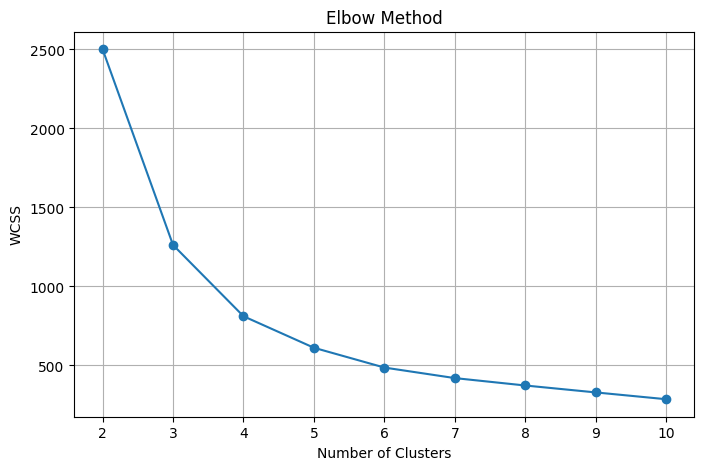

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [16]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(X)

In [17]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, rfm["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.6506334456349174


In [18]:
import pickle

# Save KMeans model
with open("customer_segmentation.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save customer segments
rfm.to_csv("customer_segments.csv", index=False)

print("✅ Customer Segmentation Completed")

✅ Customer Segmentation Completed
